# Notebook 2 - Rainfall: was the 2025/26 wet season wetter?

<a target="_blank" href="https://colab.research.google.com/github/khouakhi/UMP_EO_training/blob/main/notebooks/02_rainfall_chirps_anomaly.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


## Why rainfall first?

**Vegetation** and **temporary water** (floods, soil moisture) usually follow **rainfall** with a time lag. [**CHIRPS Daily**](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY) gives a **daily gridded rainfall** estimate suitable for regional comparisons.

**Season name:** we use the **extended winter–spring wet season (December–April)**. Each window is identified by the **April** that closes it, for example **wet season 2025/26** runs from **1 December 2025** through **30 April 2026**. Dates are built in **`wet_season_filter_dates`** in the AOI cell.

## Research questions

1. Was the **wet season ending April 2026** wetter than the **wet season ending April 2025** inside the AOI?
2. How do both compare to the **mean of wet seasons ending April 2017 through April 2024**?

## What you will produce

- **Geemap** maps of **total wet-season rainfall** ([**CHIRPS Daily**](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY)) for **2024/25**, **2025/26**, and the baseline mean, each with a **colour bar** in millimetres.
- A map of **2025/26 vs baseline** as **percentage change** (with a **colour bar** in **%**).
- A **simple bar chart** of AOI-mean rainfall for the three cases.

**Time tip:** about **30–35 minutes**.


In [1]:
# Install packages (Colab often needs a fresh install each session)
# !pip install -q earthengine-api geemap

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# If you run this notebook locally, run `ee.Authenticate()` once before `ee.Initialize`.
# If the Colab pop-up fails, try: ee.Authenticate(auth_mode="colab")
# Mapping notebooks use `Map.add_basemap("SATELLITE")` so you always have photo context under EE layers.


In [3]:
# Connect to Google Earth Engine using your cloud project ID.
# Set this to your own Google Earth Engine cloud project ID before running.
EE_PROJECT = "YOUR_GEE_PROJECT_ID"

try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

print("Earth Engine initialised with project:", EE_PROJECT)


Earth Engine initialised with project: ee-gee-hydro


In [4]:
# Study area: Moulouya basin - HydroSHEDS level-8 hydrological unit (WWF)
# Dataset: WWF/HydroSHEDS/v1/Basins/hybas_8 - use the same HYBAS_ID in every notebook for consistency.

HYBAS_ID = 1080030220

MOULOUYA_BASIN_H08 = ee.FeatureCollection("WWF/HydroSHEDS/v1/Basins/hybas_8").filter(
    ee.Filter.eq("HYBAS_ID", HYBAS_ID)
)

# Geometry used for clips, filterBounds, reduceRegion, etc.
LOWER_MOULOUYA_AOI = MOULOUYA_BASIN_H08.geometry()

# Extended winter–spring wet season (December–April), named by the April that closes the window.


def wet_season_filter_dates(april_year: int) -> tuple[str, str]:
    # Returns filterDate(start, end) with end exclusive; April is fully included.
    start = f"{april_year - 1}-12-01"
    end = f"{april_year}-05-01"
    return (start, end)


def wet_season_total_chirps(april_year: int) -> ee.Image:
    # CHIRPS total rainfall (mm) for one wet season, clipped to the basin, band P.
    start, end = wet_season_filter_dates(april_year)
    return (
        ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
        .filterDate(start, end)
        .sum()
        .clip(LOWER_MOULOUYA_AOI)
        .rename("P")
    )


def aoi_mean_mm(img: ee.Image) -> float:
    # Mean of band P over the basin (CHIRPS grid ~5.5 km).
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=LOWER_MOULOUYA_AOI,
        scale=5500,
        maxPixels=1e13,
        tileScale=4,
    )
    return float(stats.getInfo()["P"])


def aoi_max_p_mm(img: ee.Image) -> float:
    # Largest band-P value in the basin (wettest CHIRPS cell), handy for map legend tops.
    stats = img.select("P").reduceRegion(
        reducer=ee.Reducer.max(),
        geometry=LOWER_MOULOUYA_AOI,
        scale=5500,
        maxPixels=1e13,
        tileScale=4,
    )
    return float(stats.getInfo()["P"])


## Wet-season rainfall (CHIRPS)

The AOI cell already defines **`wet_season_total_chirps(april_year)`** (sums [**CHIRPS Daily**](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY) over each wet season), **`aoi_mean_mm(image)`** (basin mean of band **P**), and **`aoi_max_p_mm(image)`** (wettest grid cell in the basin). This cell **calls** the first two for the printed means; **`aoi_max_p_mm`** is used in the map cell for the legend top.

**Baseline:** mean of eight wet seasons **ending April 2017 … April 2024**.


In [5]:
P_apr2025 = wet_season_total_chirps(2025)
P_apr2026 = wet_season_total_chirps(2026)

baseline_years = list(range(2017, 2025))
baseline_mean = ee.ImageCollection([wet_season_total_chirps(yr) for yr in baseline_years]).mean().rename("P")

m_apr2025 = aoi_mean_mm(P_apr2025)
m_apr2026 = aoi_mean_mm(P_apr2026)
mbase = aoi_mean_mm(baseline_mean)

print(f"AOI mean wet-season total (mm) - 2024/25: {m_apr2025:.1f}")
print(f"AOI mean wet-season total (mm) - 2025/26: {m_apr2026:.1f}")
print(f"AOI mean wet-season total (mm) - baseline (Apr 2017-2024): {mbase:.1f}")


AOI mean wet-season total (mm) - 2024/25: 171.5
AOI mean wet-season total (mm) - 2025/26: 287.6
AOI mean wet-season total (mm) - baseline (Apr 2017-2024): 175.5


## Maps

**Basemap:** Google Satellite sits under the [**CHIRPS**](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY) layers so you can relate rainfall to real land cover.

**Legend max (`max_p`):** the AOI cell defines **`aoi_max_p_mm(image)`**, the **wettest CHIRPS cell** in the basin for that layer. We take the **largest** of the three seasons and set **`vis["max"]`** a little above that so the palette is not washed out. **`Map.remove_colorbars()`** before **`add_colorbar`** avoids stacking duplicate scales when you **re-run** the cell (geemap would otherwise keep adding another colour bar each time).


In [6]:
max_p = max(
    aoi_max_p_mm(P_apr2025),
    aoi_max_p_mm(P_apr2026),
    aoi_max_p_mm(baseline_mean),
)
vis = {
    "min": 0,
    "max": min(900, max(100, int(max_p + 50))),
    "palette": ["fff7d6", "6baed6", "08306b"],
}
aoi_vis = {"color": "red"}

print("Wettest cell in AOI (mm), max of three layers:", round(max_p, 1), "| legend max (mm):", vis["max"])

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(LOWER_MOULOUYA_AOI, 9)
Map.addLayer(P_apr2025, vis, "P Apr25")
Map.addLayer(P_apr2026, vis, "P Apr26")
Map.addLayer(baseline_mean, vis, "P base")
Map.addLayer(LOWER_MOULOUYA_AOI, aoi_vis, "AOI", opacity=0.25)
Map.remove_colorbars()
Map.add_colorbar(vis, label="mm", orientation="horizontal", position="bottomright")
Map


Wettest cell in AOI (mm), max of three layers: 385.8 | legend max (mm): 435


Map(center=[34.88374700771184, -2.5725774983515297], controls=(WidgetControl(options=['position', 'transparent…

## Anomaly map (wet season 2025/26 vs baseline, **% change**)

We map **relative** departure from the [**CHIRPS**](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY) baseline mean, not millimetres:

**100 × (wet season 2025/26 − baseline) ÷ baseline** (per pixel).

Dividing by **very small** baseline totals would blow up percentages, so the denominator uses **`baseline_mean.max(10)`**; treat each pixel’s baseline as **at least 10 mm** before dividing. **Positive** values = wetter than the long-term reference; **negative** = drier.

**`vis_anom`** is a **symmetric** **±100 %** palette; **`Map2.add_colorbar(vis_anom, …)`** uses **`label="%"`**. Values beyond ±100 % clip to the palette ends.


In [7]:
# Percent change vs baseline (mm -> %); floor baseline at 10 mm to limit divide-by-near-zero.
den = baseline_mean.max(10)
anom = P_apr2026.subtract(baseline_mean).divide(den).multiply(100).rename("dP_pct")
vis_anom = {"min": -100, "max": 100, "palette": ["d73027", "ffffbf", "1a9850"]}
aoi_vis = {"color": "333333"}

Map2 = geemap.Map()
Map2.add_basemap("SATELLITE")
Map2.centerObject(LOWER_MOULOUYA_AOI, 9)
Map2.addLayer(anom, vis_anom, "P % Apr26")
Map2.addLayer(LOWER_MOULOUYA_AOI, aoi_vis, "AOI", opacity=0.2)
Map2.remove_colorbars()
Map2.add_colorbar(vis_anom, label="%", orientation="horizontal", position="bottomright")
Map2


Map(center=[34.88374700771184, -2.5725774983515297], controls=(WidgetControl(options=['position', 'transparent…

## Bar chart (AOI means)


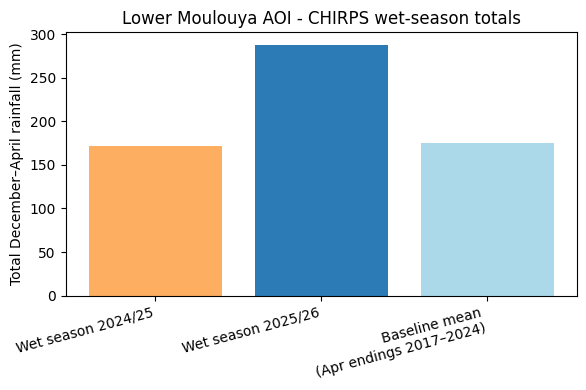

In [8]:
df = pd.DataFrame(
    {
        "Season": ["Wet season 2024/25", "Wet season 2025/26", "Baseline mean\n(Apr endings 2017–2024)"],
        "Rainfall_mm": [m_apr2025, m_apr2026, mbase],
    }
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df["Season"], df["Rainfall_mm"], color=["#fdae61", "#2c7bb6", "#abd9e9"])
ax.set_ylabel("Total December–April rainfall (mm)")
ax.set_title("Lower Moulouya AOI - CHIRPS wet-season totals")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## Discuss

1. Is **2025/26** clearly wetter than **2024/25** in the AOI mean? On the **% change** map, is **2025/26** above baseline **everywhere**, or only in patches?
2. Where might **orography** (terrain) concentrate rainfall inside the AOI?
3. Where the baseline is **naturally low**, does the **%** map overstate the story compared to the **absolute** totals map?

**Next:** `03_surface_water_change.ipynb`.
